# PLOTS RESULTATS

In [1]:
import argparse
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

ALGOS =  ["gzip", "bzip2", "genozip", "mfcompress",  "naf", "geco3", "paq8l"]

def clean_filename(name: str) -> str:
    """
    Converteix un nom de label en un nom de fitxer segur.
    """
    return (
        name.lower()
        .replace(" ", "_")
        .replace("/", "_")
        .replace("\\", "_")
        .replace(":", "_")
        .replace(",", "")
        .replace("(", "")
        .replace(")", "")
    )

def plot_scatter_by_label(df: pd.DataFrame, output_dir: Path, option: str = "compression"):
    output_dir.mkdir(parents=True, exist_ok=True)

    labels = sorted(df["plot_label"].dropna().unique())

    for label in labels:
        subdf = df[df["plot_label"] == label].copy()

        if subdf.empty:
            continue

        plt.figure(figsize=(10, 6))

        for algo in sorted(subdf["algorithm"].dropna().unique()):
            algo_df = subdf[subdf["algorithm"] == algo]
            
            if option in ("compression", "c"):
                plt.scatter(
                    algo_df["compress_seconds"],
                    algo_df["bits_per_base_total"],
                    label=algo,
                    alpha=0.8
                )
                plt.xlabel("Temps de compressió (s)")
            elif option in ("decompression", "d"):
                plt.scatter(
                    algo_df["decompress_seconds"],
                    algo_df["bits_per_base_total"],
                    label=algo,
                    alpha=0.8
                )
                plt.xlabel("Temps de descompressió (s)")
            else: 
                plt.scatter(
                    algo_df["compress_seconds"]+algo_df["decompress_seconds"],
                    algo_df["bits_per_base_total"],
                    label=algo,
                    alpha=0.8
                )
                plt.xlabel("Temps de compressió + descompressió (s)")

        plt.ylabel("Compressió obtinguda (bpb)")
        plt.title(f"Temps vs taxa de compressió - {label}")

        mean_entropy = subdf["entropy_acgt_bits_per_base"].mean()
        min_entropy = subdf["entropy_acgt_bits_per_base"].min()
        max_entropy = subdf["entropy_acgt_bits_per_base"].max()
        plt.axhline(mean_entropy, color="black", linestyle="-", label=f"H0 mitjana: {mean_entropy:.2f} bpb")
        plt.axhline(min_entropy, color="grey", linestyle=":", label=f"H0 mínima: {min_entropy:.2f} bpb")
        plt.axhline(max_entropy, color="grey", linestyle=":", label=f"H0 màxima: {max_entropy:.2f} bpb")

        # Fer que els eixos comencin sempre a 0
        plt.xlim(left=0)
        plt.ylim(bottom=0)

        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()

        out_path = output_dir / f"scatter_compression_time_vs_ratio_{clean_filename(label)}_geco3_paq8l.png"
        plt.savefig(out_path, dpi=300)
        plt.close()

        print(f"[OK] Plot guardat: {out_path}")

def plot_scatter_by_label_MBps(df: pd.DataFrame, output_dir: Path, option: str = "compression"):
    output_dir.mkdir(parents=True, exist_ok=True)

    labels = sorted(df["plot_label"].dropna().unique())

    for label in labels:
        subdf = df[df["plot_label"] == label].copy()

        if subdf.empty:
            continue

        plt.figure(figsize=(10, 6))

        for algo in sorted(subdf["algorithm"].dropna().unique()):
            algo_df = subdf[subdf["algorithm"] == algo]
            
            if option in ("compression", "c"):
                plt.scatter(
                    algo_df["compress_MBps"],
                    algo_df["bits_per_base_total"],
                    label=algo,
                    alpha=0.8
                )
                plt.xlabel("Velocitat de compressió (MB/s)")
            elif option in ("decompression", "d"):
                plt.scatter(
                    algo_df["decompress_MBps"],
                    algo_df["bits_per_base_total"],
                    label=algo,
                    alpha=0.8
                )
                plt.xlabel("Velocitat de descompressió (MB/s)")
            else: 
                plt.scatter(
                    (algo_df["compress_MBps"]+algo_df["decompress_MBps"])/2,
                    algo_df["bits_per_base_total"],
                    label=algo,
                    alpha=0.8
                )
                plt.xlabel("Velocitat mitjana de compressió i descompressió (MB/s)")

        plt.ylabel("Compressió obtinguda (bpb)")
        plt.title(f"Velocitat vs taxa de compressió - {label}")

        mean_entropy = subdf["entropy_acgt_bits_per_base"].mean()
        min_entropy = subdf["entropy_acgt_bits_per_base"].min()
        max_entropy = subdf["entropy_acgt_bits_per_base"].max()
        plt.axhline(mean_entropy, color="black", linestyle="-", label=f"H0 mitjana: {mean_entropy:.2f} bpb")
        plt.axhline(min_entropy, color="grey", linestyle=":", label=f"H0 mínima: {min_entropy:.2f} bpb")
        plt.axhline(max_entropy, color="grey", linestyle=":", label=f"H0 màxima: {max_entropy:.2f} bpb")

        # Fer que els eixos comencin sempre a 0
        plt.xlim(left=0)
        plt.ylim(bottom=0)

        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()

        out_path = output_dir / f"scatter_compression_velocity_vs_ratio_{clean_filename(label)}.png"
        plt.savefig(out_path, dpi=300)
        plt.close()

        print(f"[OK] Plot guardat: {out_path}")


def parse_args():
    parser = argparse.ArgumentParser(
        description="Genera plots de temps vs taxa de compressió a partir d'un CSV."
    )

    parser.add_argument(
        "csv_path",
        type=Path,
        help="Camí al fitxer CSV amb els resultats."
    )

    parser.add_argument(
        "--time-option",
        "-t",
        choices=["compression", "c", "decompression", "d", "total", "t"],
        default="total",
        help="Tipus de temps a representar: compression, decompression o total. Per defecte: total."
    )

    parser.add_argument(
        "--output-dir",
        "-o",
        type=Path,
        default=None,
        help="Directori de sortida dels plots. Si no s'indica, es crea automàticament a partir del timestamp del CSV."
    )

    return parser.parse_args()


def main():

    args = parse_args()
    csv_path = args.csv_path
    TIMESTAMP = csv_path.stem.split("_")[-6] + "_" + csv_path.stem.split("_")[-5] + "_" + csv_path.stem.split("_")[-4] + "_" + csv_path.stem.split("_")[-3] + "_" + csv_path.stem.split("_")[-2] + "_" + csv_path.stem.split("_")[-1]
    generic_output_dir = Path(f"/home/helen/genomic_benchmark/results/{TIMESTAMP}/plots")
    output_dir = args.output_dir if args.output_dir else generic_output_dir
    TIME_OPTION = args.time_option

    df = pd.read_csv(csv_path)

    required_columns = {
        "dataset_id",
        "dataset_label",
        "algorithm",
        "bits_per_base_total",
        "bits_per_base_seq",
        "compress_seconds",
        "decompress_seconds",
        "compress_MBps",
        "decompress_MBps",
        "status",
        "entropy_acgt_bits_per_base"
    }

    missing = required_columns - set(df.columns)
    if missing:
        raise ValueError(f"Falten columnes al CSV: {missing}")

    # Convertir columnes numèriques per evitar errors si hi ha valors buits
    df["bits_per_base_total"] = pd.to_numeric(df["bits_per_base_total"], errors="coerce")
    df["bits_per_base_seq"] = pd.to_numeric(df["bits_per_base_seq"], errors="coerce")
    df["compress_seconds"] = pd.to_numeric(df["compress_seconds"], errors="coerce")
    df["decompress_seconds"] = pd.to_numeric(df["decompress_seconds"], errors="coerce")
    df["compress_MBps"] = pd.to_numeric(df["compress_MBps"], errors="coerce")
    df["decompress_MBps"] = pd.to_numeric(df["decompress_MBps"], errors="coerce")
    df["entropy_acgt_bits_per_base"] = pd.to_numeric(df["entropy_acgt_bits_per_base"], errors="coerce")

    # Filtrar files sense valors útils
    df = df.dropna(subset=["bits_per_base_total", "bits_per_base_seq", "compress_seconds", "decompress_seconds", "compress_MBps", "decompress_MBps", "entropy_acgt_bits_per_base"])

    df = df[df["status"].isin(["ok", "ok_noN"])]

    # Crear la columna plot_label a partir de dataset_label
    df["plot_label"] = df["dataset_label"]

    # Filtrar només els algorismes d'interès
    df = df[df["algorithm"].isin(ALGOS)]

    df = df[df["status"].isin(["ok", "ok_noN"])]

    if df.empty:
        print("[WARNING] No hi ha dades vàlides per fer plots.")
        return

    plot_scatter_by_label_MBps(
        df=df,
        output_dir=output_dir,
        option=TIME_OPTION  
    )


In [7]:
def plot_temps_compression_decompression(df: pd.DataFrame, label: str = ""):

    plt.figure(figsize=(10, 6))

    for algo in sorted(df["algorithm"].dropna().unique()):
        algo_df = df[df["algorithm"] == algo]
        plt.scatter(
            algo_df["compress_seconds"],
            algo_df["decompress_seconds"],
            label=algo,
            alpha=0.8
        )

    plt.xlabel("Temps de compressió (s)")
    plt.ylabel("Temps de descompressió (s)")
    plt.title(f"{label} - Temps de compressió vs descompressió")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.show()

def plot_bitrate_percent(df: pd.DataFrame, label: str = ""):
    plt.figure(figsize=(10, 6))

    for algo in sorted(df["algorithm"].dropna().unique()):
        algo_df = df[df["algorithm"] == algo]
        plt.scatter(
            algo_df["bits_per_base_seq"],
            algo_df["compression_percent"],
            label=algo,
            alpha=0.8
        )

    plt.xlabel("Bits per base seq")
    plt.ylabel("Compression Percent")
    plt.title(f"{label} - Bits per base seq vs Compression Percent")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.show()

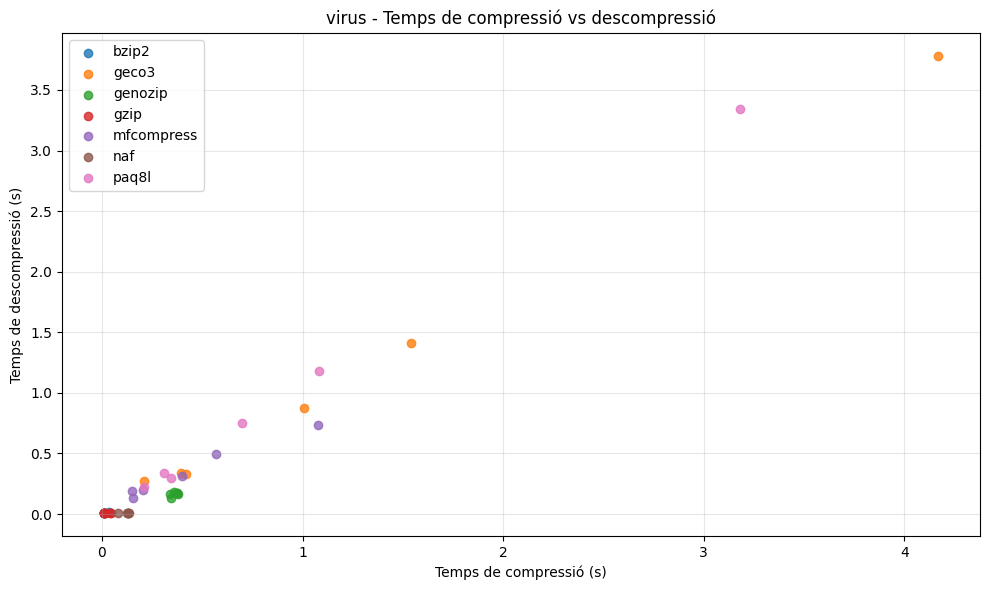

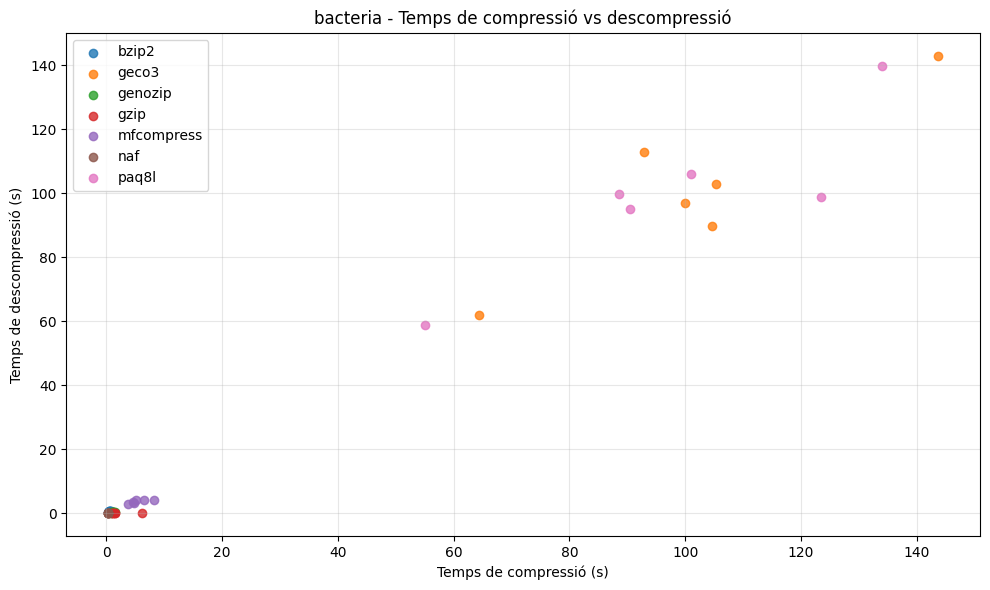

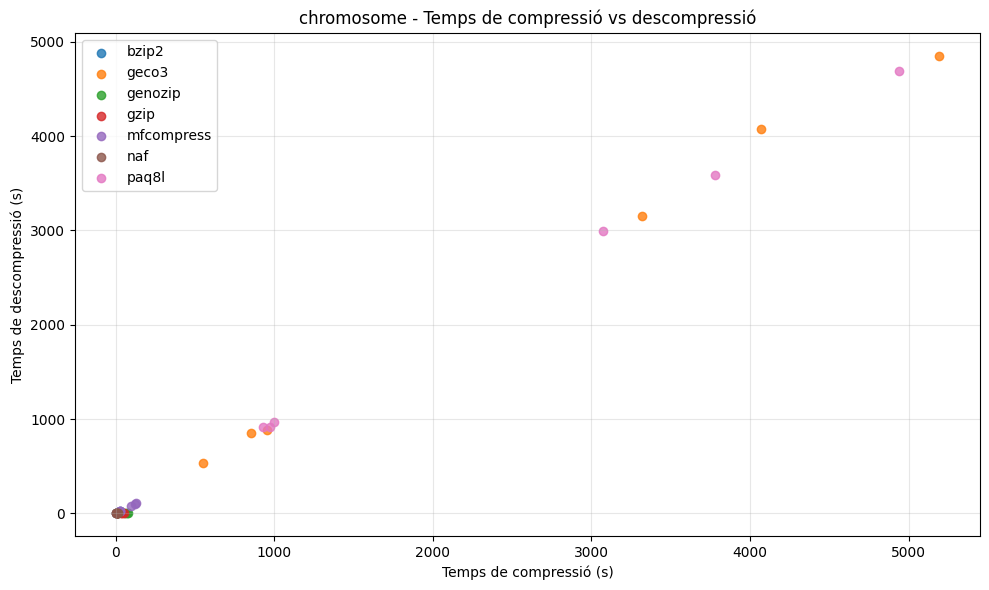

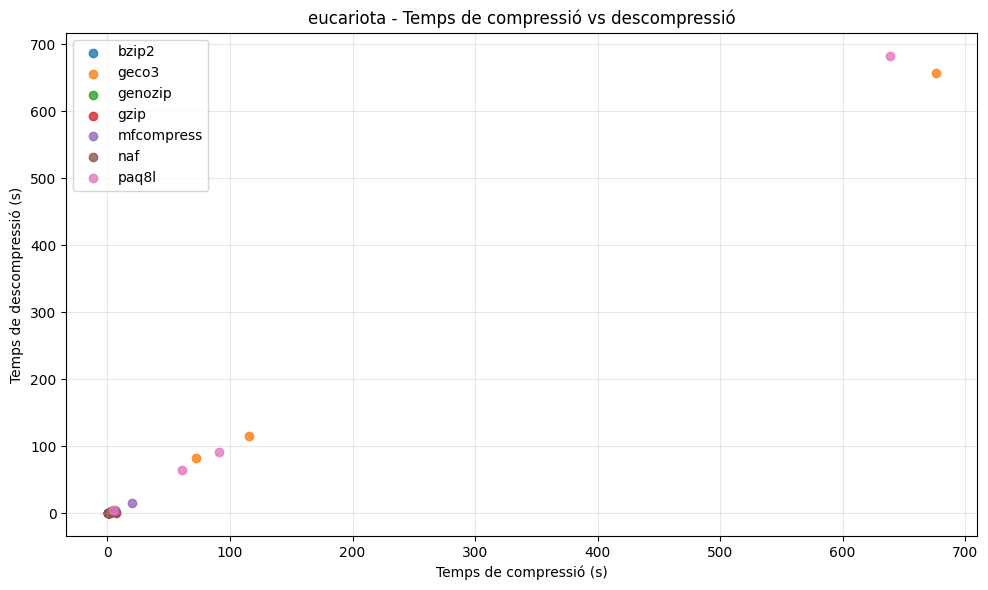

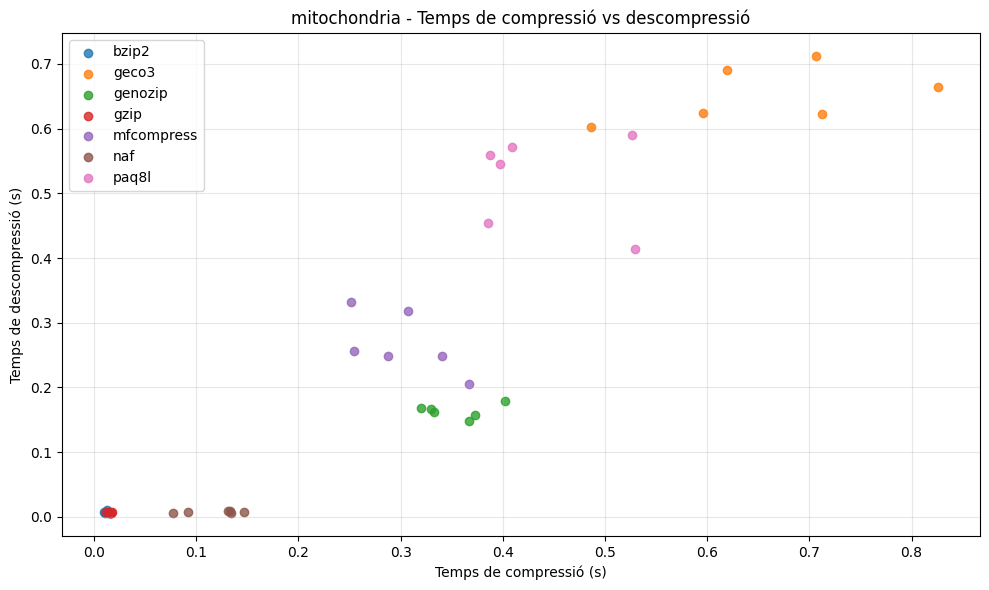

In [8]:
categories = ["virus", "bacteria", "chromosome", "eucariota", "mitochondria"]

df = pd.read_csv("comparative_results_updated.csv")
for cat in categories:
    df_aux = df[df["dataset_label"] == cat]
    plot_temps_compression_decompression(df_aux, label=cat)

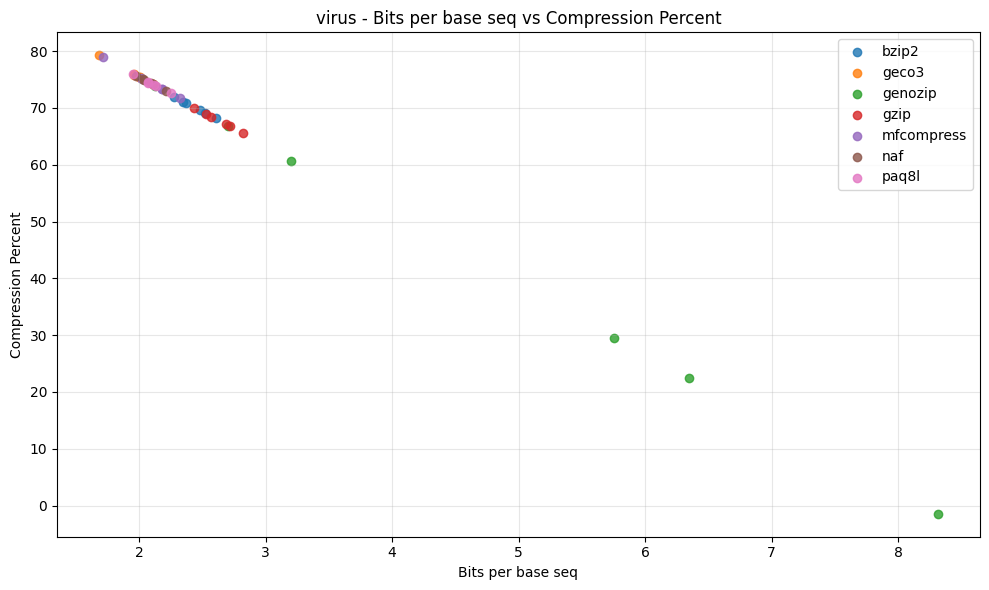

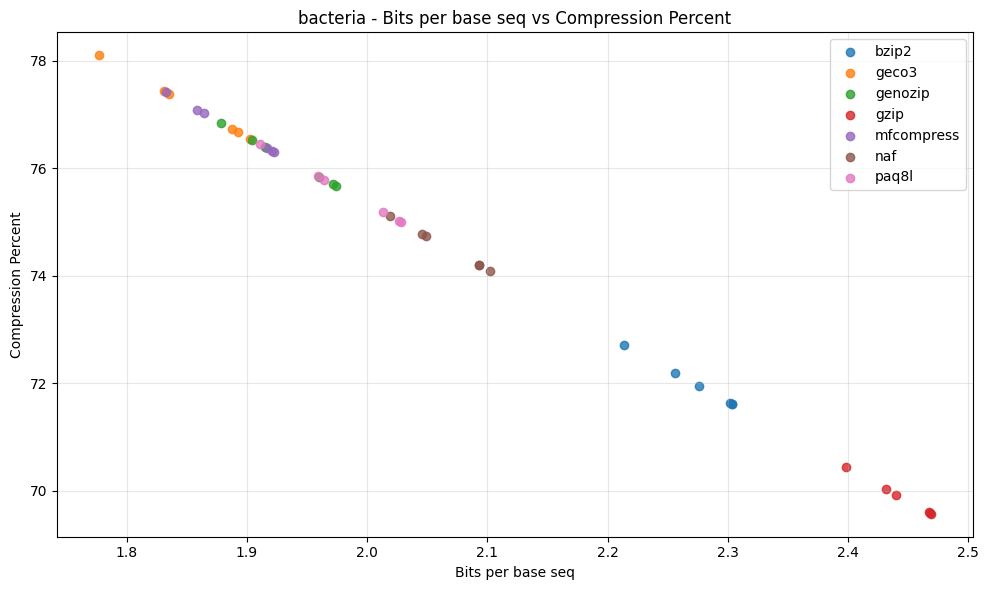

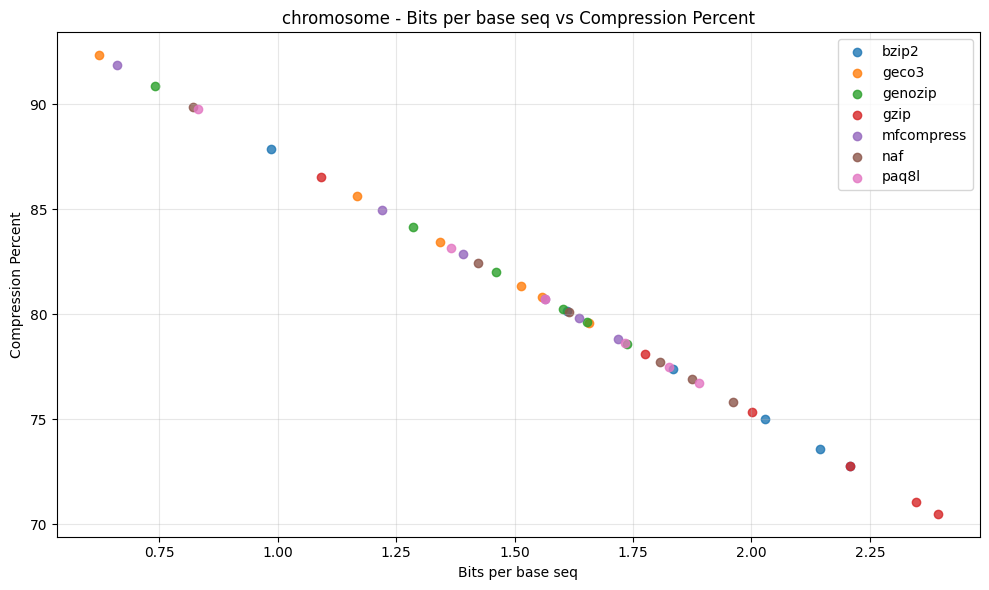

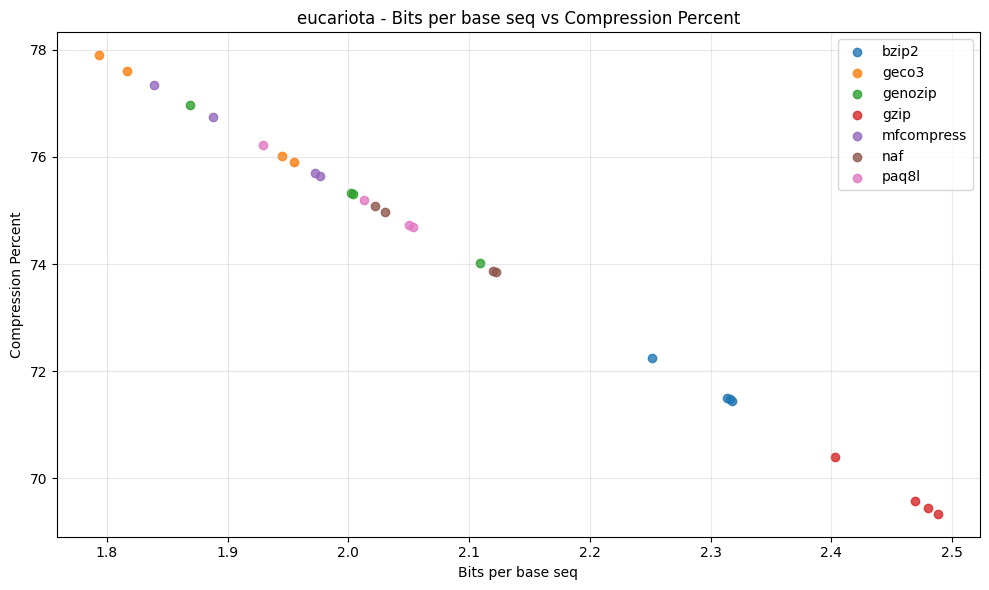

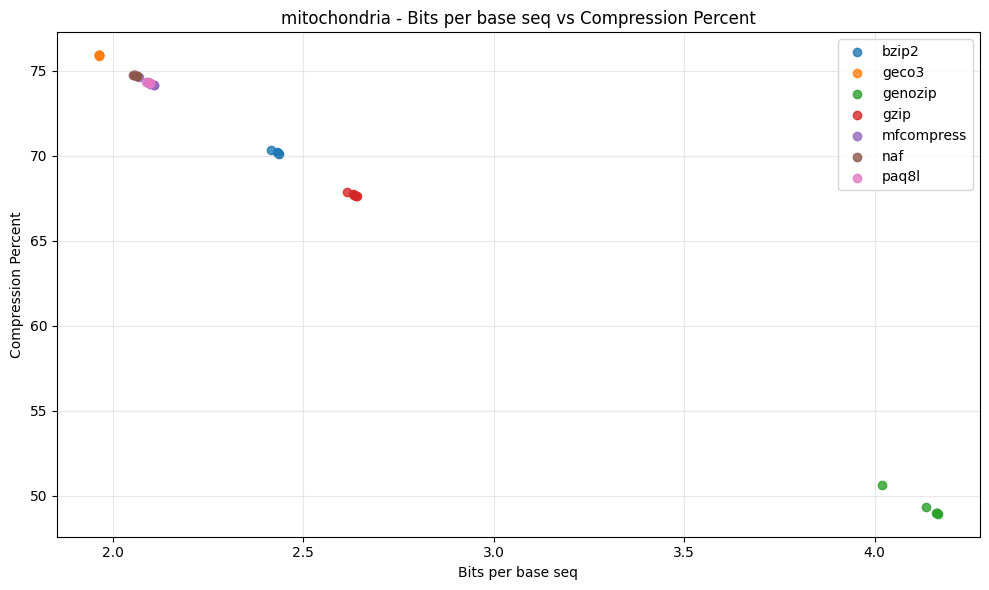

In [9]:
categories = ["virus", "bacteria", "chromosome", "eucariota", "mitochondria"]

df = pd.read_csv("comparative_results_updated.csv")
for cat in categories:
    df_aux = df[df["dataset_label"] == cat]
    plot_bitrate_percent(df_aux, label=cat)